In [53]:
import os
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [54]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from facenet_pytorch import InceptionResnetV1

In [55]:
X_train = np.load("../processing/preprocessed_data/X_train.npy") 
y_train = np.load("../processing/preprocessed_data/y_train.npy")
X_test = np.load("../processing/preprocessed_data/X_test.npy")
y_test = np.load("../processing/preprocessed_data/y_test.npy")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (32273, 48, 48, 1)
y_train shape: (32273,)
X_test shape: (7178, 48, 48, 1)
y_test shape: (7178,)


In [56]:
emotions = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
NUM_CLASSES = len(emotions)



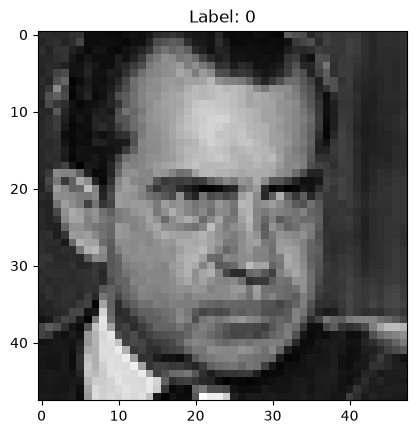

In [57]:
plt.imshow(X_train[1].reshape(48, 48), cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.show()

In [58]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


Using device: cuda


In [59]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.14.0+cu126
True


In [60]:
import torchvision.transforms as T

class FERDataset(Dataset):
    def __init__(self, X, y, img_size=IMG_SIZE, train=False):
        self.X = X
        self.y = y.astype(np.int64)
        self.img_size = img_size
        self.train = train
        if train:
            self.aug = T.Compose([
                T.RandomHorizontalFlip(p=0.5),
                T.RandomRotation(10),
                T.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
            ])

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img.squeeze(-1)
        if img.max() > 1.0:
            img = img.astype(np.float32) / 255.0
        else:
            img = img.astype(np.float32)

        img = np.stack([img, img, img], axis=0)
        tensor = torch.from_numpy(img).float()
        tensor = F.interpolate(tensor.unsqueeze(0), size=(self.img_size, self.img_size),
                                mode="bilinear", align_corners=False).squeeze(0)

        if self.train:
            tensor = self.aug(tensor)   # augmentation بعد الـ resize

        tensor = (tensor - 0.5) / 0.5
        label = self.y[idx]
        return tensor, label

In [61]:
train_dataset = FERDataset(X_train, y_train)
test_dataset = FERDataset(X_test, y_test)



In [62]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)



In [63]:
import pickle

with open("../processing/preprocessed_data/class_weight_dict.pkl", "rb") as f:
    class_weight_dict = pickle.load(f)

print(class_weight_dict)

{0: np.float64(1.1540497049883782), 1: np.float64(1.152607142857143), 2: np.float64(1.1253181770633565), 3: np.float64(0.639006039006039), 4: np.float64(0.9285858149906489), 5: np.float64(0.9545400769003254), 6: np.float64(1.4539352164706942)}


In [64]:
# نتأكد إن الترتيب صح حسب أرقام الـ classes (0 لحد 6)
class_weights_array = np.array([class_weight_dict[i] for i in range(NUM_CLASSES)])
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(DEVICE)

print("Class weights:", dict(zip(emotions, class_weights_array)))

Class weights: {'angry': np.float64(1.1540497049883782), 'disgust': np.float64(1.152607142857143), 'fear': np.float64(1.1253181770633565), 'happy': np.float64(0.639006039006039), 'neutral': np.float64(0.9285858149906489), 'sad': np.float64(0.9545400769003254), 'surprise': np.float64(1.4539352164706942)}


In [65]:
# ============ الموديل ============
model = InceptionResnetV1(pretrained='vggface2', classify=False)
for param in model.parameters():
    param.requires_grad = False

model.logits = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512, NUM_CLASSES)
)
model.classify = True
model = model.to(DEVICE)


criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)

optimizer = torch.optim.Adam(model.logits.parameters(), lr=1e-3, weight_decay=1e-4)



In [66]:
optimizer_phase2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5, weight_decay=1e-4
)

# ابدأ بـ block8 بس + logits (بدل التلاتة مع بعض)
for name, param in model.named_parameters():
    if any(k in name for k in ["block8", "logits", "last_linear", "last_bn"]):
        param.requires_grad = True

In [67]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss / total, correct / total

In [68]:
def train_with_early_stopping(model, train_loader, val_loader, optimizer, criterion,
                                epochs, patience=3, save_path="best_model.pth", phase_name="Phase"):
    best_val_loss = float("inf")
    patience_counter = 0
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=1
    )

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        print(f"[{phase_name} {epoch+1}/{epochs}] "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✓ Saved best model (val_loss={val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(torch.load(save_path))
    return model


In [69]:
EPOCHS_PHASE1 = 15
model = train_with_early_stopping(
    model, train_loader, test_loader, optimizer, criterion,
    epochs=EPOCHS_PHASE1, patience=3,
    save_path="best_phase1.pth", phase_name="Phase1")

[Phase1 1/15] train_loss=1.8247 train_acc=0.3109 val_loss=1.7953 val_acc=0.3377
  ✓ Saved best model (val_loss=1.7953)
[Phase1 2/15] train_loss=1.7911 train_acc=0.3225 val_loss=1.7938 val_acc=0.3330
  ✓ Saved best model (val_loss=1.7938)
[Phase1 3/15] train_loss=1.7897 train_acc=0.3217 val_loss=1.7967 val_acc=0.3332
  patience: 1/3
[Phase1 4/15] train_loss=1.7936 train_acc=0.3245 val_loss=1.7989 val_acc=0.3384
  patience: 2/3
[Phase1 5/15] train_loss=1.7607 train_acc=0.3369 val_loss=1.7709 val_acc=0.3462
  ✓ Saved best model (val_loss=1.7709)
[Phase1 6/15] train_loss=1.7553 train_acc=0.3399 val_loss=1.7829 val_acc=0.3399
  patience: 1/3
[Phase1 7/15] train_loss=1.7551 train_acc=0.3392 val_loss=1.7936 val_acc=0.3261
  patience: 2/3
[Phase1 8/15] train_loss=1.7422 train_acc=0.3465 val_loss=1.7763 val_acc=0.3523
  patience: 3/3
  Early stopping at epoch 8


In [70]:
for name, param in model.named_parameters():
    if any(k in name for k in ["block8", "logits", "last_linear", "last_bn"]):
        param.requires_grad = True

optimizer_phase2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5, weight_decay=1e-4
)

EPOCHS_PHASE2 = 15
model = train_with_early_stopping(
    model, train_loader, test_loader, optimizer_phase2, criterion,
    epochs=EPOCHS_PHASE2, patience=3,
    save_path="best_phase2.pth", phase_name="Phase2"
)



[Phase2 1/15] train_loss=1.6444 train_acc=0.4114 val_loss=1.6081 val_acc=0.4492
  ✓ Saved best model (val_loss=1.6081)
[Phase2 2/15] train_loss=1.4904 train_acc=0.5114 val_loss=1.4678 val_acc=0.5359
  ✓ Saved best model (val_loss=1.4678)
[Phase2 3/15] train_loss=1.3855 train_acc=0.5712 val_loss=1.4113 val_acc=0.5641
  ✓ Saved best model (val_loss=1.4113)
[Phase2 4/15] train_loss=1.3148 train_acc=0.6064 val_loss=1.3704 val_acc=0.5846
  ✓ Saved best model (val_loss=1.3704)
[Phase2 5/15] train_loss=1.2557 train_acc=0.6376 val_loss=1.3348 val_acc=0.6010
  ✓ Saved best model (val_loss=1.3348)
[Phase2 6/15] train_loss=1.2086 train_acc=0.6589 val_loss=1.3126 val_acc=0.6096
  ✓ Saved best model (val_loss=1.3126)
[Phase2 7/15] train_loss=1.1680 train_acc=0.6794 val_loss=1.2980 val_acc=0.6215
  ✓ Saved best model (val_loss=1.2980)
[Phase2 8/15] train_loss=1.1330 train_acc=0.6967 val_loss=1.2829 val_acc=0.6321
  ✓ Saved best model (val_loss=1.2829)
[Phase2 9/15] train_loss=1.0978 train_acc=0.7154

In [71]:
# ============ حفظ الموديل النهائي ============
torch.save(model.state_dict(), "emotion_model_facenet_final.pth")
print("Model saved.")

Model saved.
